In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import pickle
import matplotlib.pyplot as plt


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks


/content/drive/MyDrive/Colab Notebooks


In [4]:
# =========================
# PCA FUNCTION
# =========================
def apply_pca(indep_X, n):
    sc = StandardScaler()
    indep_X_scaled = sc.fit_transform(indep_X)

    pca = PCA(n_components=n)
    pca_features = pca.fit_transform(indep_X_scaled)

    return pca_features

In [5]:
# =========================
# SPLIT FUNCTION
# =========================
def split_scalar(indep_X, dep_Y):
    X_train, X_test, y_train, y_test = train_test_split(
        indep_X, dep_Y, test_size=0.25, random_state=0
    )
    return X_train, X_test, y_train, y_test

In [6]:
# =========================
# CONFUSION MATRIX + REPORT
# =========================
def cm_prediction(classifier, X_test, y_test):
    y_pred = classifier.predict(X_test)

    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import classification_report

    cm = confusion_matrix(y_test, y_pred)
    Accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    return classifier, Accuracy, report, X_test, y_test, cm


In [7]:
# =========================
# LOGISTIC REGRESSION
# =========================
def logistic(X_train, y_train, X_test, y_test):
    from sklearn.linear_model import LogisticRegression

    classifier = LogisticRegression(random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm



In [8]:
# =========================
# SVM LINEAR
# =========================
def svm_linear(X_train, y_train, X_test, y_test):
    from sklearn.svm import SVC

    classifier = SVC(kernel='linear', random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm


In [9]:
# =========================
# SVM NON-LINEAR
# =========================
def svm_NL(X_train, y_train, X_test, y_test):
    from sklearn.svm import SVC

    classifier = SVC(kernel='rbf', random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm


In [10]:
# =========================
# NAIVE BAYES
# =========================
def Navie(X_train, y_train, X_test, y_test):
    from sklearn.naive_bayes import GaussianNB

    classifier = GaussianNB()
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm



In [11]:
# =========================
# KNN
# =========================
def knn(X_train, y_train, X_test, y_test):
    from sklearn.neighbors import KNeighborsClassifier

    classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm



In [12]:
# =========================
# DECISION TREE
# =========================
def Decision(X_train, y_train, X_test, y_test):
    from sklearn.tree import DecisionTreeClassifier

    classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm


In [13]:
# =========================
# RANDOM FOREST
# =========================
def random(X_train, y_train, X_test, y_test):
    from sklearn.ensemble import RandomForestClassifier

    classifier = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm

In [14]:
# =========================
# RESULT TABLE
# =========================
def pca_Classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf):
    dataframe = pd.DataFrame(
        index=['PCA'],
        columns=['Logistic', 'SVMl', 'SVMnl', 'KNN', 'Navie', 'Decision', 'Random']
    )

    for number, idex in enumerate(dataframe.index):
        dataframe['Logistic'][idex] = acclog[number]
        dataframe['SVMl'][idex] = accsvml[number]
        dataframe['SVMnl'][idex] = accsvmnl[number]
        dataframe['KNN'][idex] = accknn[number]
        dataframe['Navie'][idex] = accnav[number]
        dataframe['Decision'][idex] = accdes[number]
        dataframe['Random'][idex] = accrf[number]

    return dataframe


In [15]:
# =========================
# LOAD DATASET
# =========================
dataset1 = pd.read_csv("Wine.csv", index_col=None)

df2 = dataset1.copy()

# Convert categorical columns to dummy
df2 = pd.get_dummies(df2, drop_first=True)

# Display available columns to help identify the correct target variable
print("Available columns after get_dummies:", df2.columns.tolist())


Available columns after get_dummies: ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline', 'Customer_Segment']


In [16]:
# Features and target
# The original error was: KeyError: "['classification_yes'] not found in axis"
# This means the column 'classification_yes' does not exist in df2.
# Please inspect the output above and replace 'your_actual_target_column' with the correct name.
# For example, if your target column is named 'Class_2', you would use:
# indep_X = df2.drop('Class_2', axis=1)
# dep_Y = df2['Class_2']

# Corrected lines using the identified target column 'Customer_Segment'
indep_X = df2.drop('Customer_Segment', axis=1)
dep_Y = df2['Customer_Segment']

In [17]:
# =========================
# APPLY PCA
# =========================
# Determine the number of components for PCA. A common choice is to retain components explaining a certain percentage of variance, or a fixed number.
# For now, let's assume we want to reduce to 2 principal components. Adjust 'n_components' as needed.
n_components = 2 # Example: You might want to analyze variance explained to choose this.
pca_data = apply_pca(indep_X, n_components)

In [18]:
# =========================
# INITIALIZE ACCURACY LISTS
# =========================
acclog = []
accsvml = []
accsvmnl = []
accknn = []
accnav = []
accdes = []
accrf = []

In [19]:
# =========================
# SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = split_scalar(pca_data, dep_Y)


In [20]:

# =========================
# TRAIN ALL MODELS
# =========================
classifier, Accuracy, report, X_test, y_test, cm = logistic(X_train, y_train, X_test, y_test)
acclog.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = svm_linear(X_train, y_train, X_test, y_test)
accsvml.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = svm_NL(X_train, y_train, X_test, y_test)
accsvmnl.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = knn(X_train, y_train, X_test, y_test)
accknn.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = Navie(X_train, y_train, X_test, y_test)
accnav.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = Decision(X_train, y_train, X_test, y_test)
accdes.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = random(X_train, y_train, X_test, y_test)
accrf.append(Accuracy)

In [21]:
def pca_Classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf):
    dataframe = pd.DataFrame({
        'Logistic': [acclog[0]],
        'SVMl': [accsvml[0]],
        'SVMnl': [accsvmnl[0]],
        'KNN': [accknn[0]],
        'Navie': [accnav[0]],
        'Decision': [accdes[0]],
        'Random': [accrf[0]]
    }, index=['PCA'])

    return dataframe

In [22]:
def pca_classification(acclog, accsvm1, accsvmn1, accknn, accnav, accdes, accrf):
    dataframe = pd.DataFrame({
        'Logistic': [acclog[0]],
        'SVM1': [accsvm1[0]],
        'SVMn1': [accsvmn1[0]],
        'KNN': [accknn[0]],
        'Navie': [accnav[0]],
        'Decision': [accdes[0]],
        'Random': [accrf[0]]
    }, index=['PCA'])

    return dataframe


Logistic Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

SVM Linear Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

SVM RBF Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

KNN Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Naive Bayes Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Decision Tree Confusion Matrix:
[[14  0  0]
 [ 1 13  0]
 [ 0  0  8]]

Random Forest Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Final Results:
           Model  Accuracy  Precision    Recall  F1 Score
0       Logistic  1.000000   1.000000  1.000000  1.000000
1     SVM Linear  1.000000   1.000000  1.000000  1.000000
2        SVM RBF  1.000000   1.000000  1.000000  1.000000
3            KNN  1.000000   1.000000  1.000000  1.000000
4    Naive Bayes  1.000000   1.000000  1.000000  1.000000
5  Decision Tree  0.972222   0.974074  0.972222  0.972187
6  Random Forest  1.000000   1.000000  1.000000  1.000000


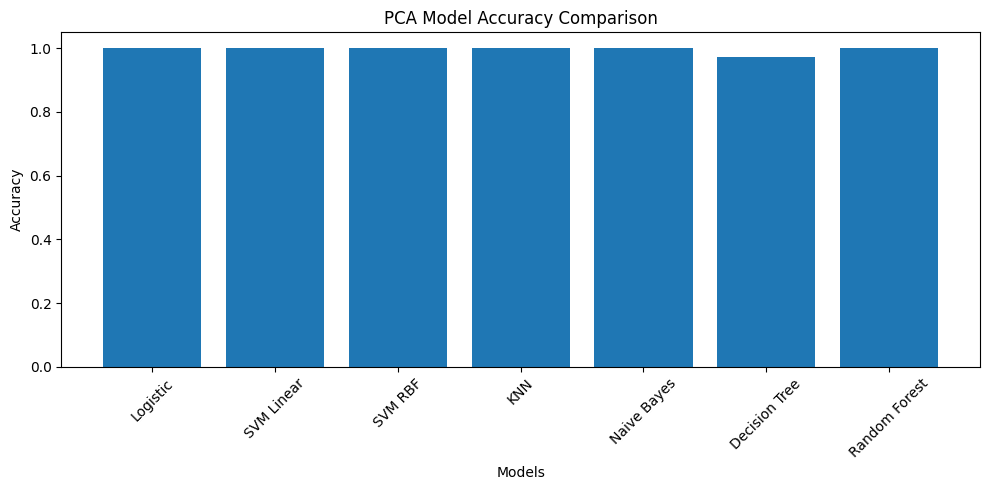

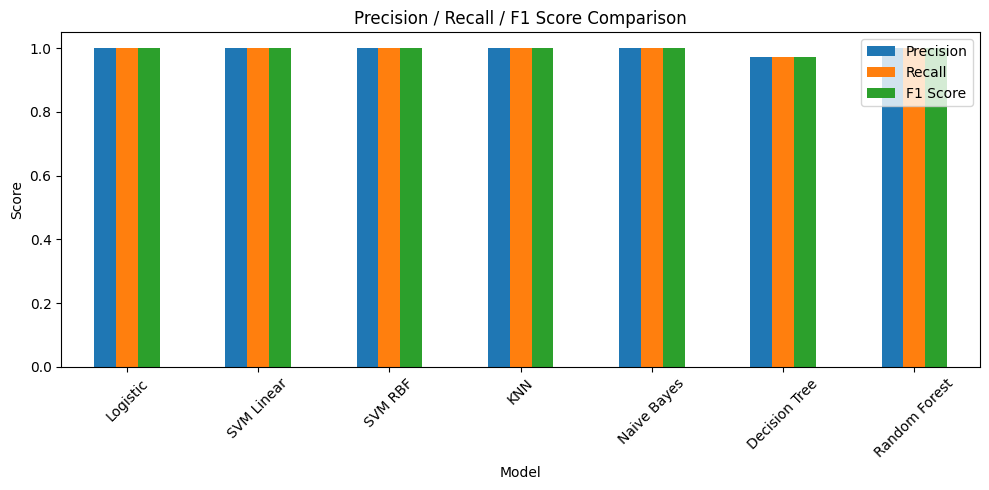

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =========================
# 1. LOAD DATASET
# =========================
df = pd.read_csv("Wine.csv")   # change your file name

# Last column = target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# =========================
# 2. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. SCALING
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 4. PCA
# =========================
pca = PCA(n_components=2)   # change if needed
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# =========================
# 5. MODELS
# =========================
models = {
    "Logistic": LogisticRegression(),
    "SVM Linear": SVC(kernel='linear'),
    "SVM RBF": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# =========================
# 6. TRAIN + PREDICT + METRICS
# =========================
results = []

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name} Confusion Matrix:")
    print(cm)

# =========================
# 7. RESULTS TABLE
# =========================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\nFinal Results:")
print(results_df)

# =========================
# 8. ACCURACY BAR CHART
# =========================
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("PCA Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 9. METRICS BAR CHART
# =========================
results_df.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10,5))
plt.title("Precision / Recall / F1 Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score
0       Logistic  1.000000   1.000000  1.000000  1.000000
1     SVM Linear  1.000000   1.000000  1.000000  1.000000
2        SVM RBF  1.000000   1.000000  1.000000  1.000000
3            KNN  1.000000   1.000000  1.000000  1.000000
4    Naive Bayes  1.000000   1.000000  1.000000  1.000000
5  Decision Tree  0.972222   0.974074  0.972222  0.972187
6  Random Forest  1.000000   1.000000  1.000000  1.000000


In [32]:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [33]:
print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score
0       Logistic  1.000000   1.000000  1.000000  1.000000
1     SVM Linear  1.000000   1.000000  1.000000  1.000000
2        SVM RBF  1.000000   1.000000  1.000000  1.000000
3            KNN  1.000000   1.000000  1.000000  1.000000
4    Naive Bayes  1.000000   1.000000  1.000000  1.000000
5  Decision Tree  0.972222   0.974074  0.972222  0.972187
6  Random Forest  1.000000   1.000000  1.000000  1.000000


In [34]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.35900066 0.18691934 0.11606557 0.07371716 0.0665386  0.04854582
 0.04195042 0.02683922 0.0234746  0.01889734]
Total Variance Retained: 0.9619487172898267


In [37]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [38]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.35900066 0.18691934 0.11606557 0.07371716 0.0665386 ]
Total Variance Retained: 0.8022413242841142


In [39]:
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [40]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.35900066 0.18691934 0.11606557]
Total Variance Retained: 0.6619855707386526


In [41]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [42]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.35900066 0.18691934]
Total Variance Retained: 0.54592000222866


In [43]:
print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score
0       Logistic  1.000000   1.000000  1.000000  1.000000
1     SVM Linear  1.000000   1.000000  1.000000  1.000000
2        SVM RBF  1.000000   1.000000  1.000000  1.000000
3            KNN  1.000000   1.000000  1.000000  1.000000
4    Naive Bayes  1.000000   1.000000  1.000000  1.000000
5  Decision Tree  0.972222   0.974074  0.972222  0.972187
6  Random Forest  1.000000   1.000000  1.000000  1.000000


In [45]:
import pandas as pd

summary_table = pd.DataFrame({
    "PCA Components": [2, 3, 5, 10],
    "Total Variance Retained": [0.5459, 0.6620, 0.8022, 0.9619],
    "Variance %": ["54.59%", "66.20%", "80.22%", "96.19%"],
    "Accuracy (Best Models)": [1.0000, 1.0000, 1.0000, 1.0000],
    "Decision Tree Accuracy": [0.9722, 0.9722, 0.9722, 0.9722]
})

print(summary_table)

   PCA Components  Total Variance Retained Variance %  Accuracy (Best Models)  \
0               2                   0.5459     54.59%                     1.0   
1               3                   0.6620     66.20%                     1.0   
2               5                   0.8022     80.22%                     1.0   
3              10                   0.9619     96.19%                     1.0   

   Decision Tree Accuracy  
0                  0.9722  
1                  0.9722  
2                  0.9722  
3                  0.9722  
